# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

In [67]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv('marketing_campaign.csv', delimiter=';')

In [5]:
df.head(10)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
5,1967,Master,Together,62513.0,0,16,520,42,98,0,42,14,10,6,0,1
6,1971,Graduation,Divorced,55635.0,0,34,235,65,164,50,49,27,7,6,0,1
7,1985,PhD,Married,33454.0,1,32,76,10,56,3,1,23,4,8,0,1
8,1974,PhD,Together,30351.0,1,19,14,0,24,3,3,2,2,9,0,0
9,1950,PhD,Together,5648.0,1,68,28,0,6,1,1,13,0,20,0,0


In [6]:
df.shape

(2240, 16)

In [7]:
print("Menor ano:", df["Year_Birth"].min())
print("Maior ano:", df["Year_Birth"].max())

Menor ano: 1893
Maior ano: 1996


In [8]:
df = df[df["Year_Birth"] >= 1950]
#estipulei idade máxima de 76 anos

In [9]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'WebPurchases'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 2130 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2130 non-null   int64  
 1   Education          2130 non-null   str    
 2   Marital_Status     2130 non-null   str    
 3   Income             2107 non-null   float64
 4   Kidhome            2130 non-null   int64  
 5   Recency            2130 non-null   int64  
 6   MntWines           2130 non-null   int64  
 7   MntFruits          2130 non-null   int64  
 8   MntMeatProducts    2130 non-null   int64  
 9   MntFishProducts    2130 non-null   int64  
 10  MntSweetProducts   2130 non-null   int64  
 11  MntGoldProds       2130 non-null   int64  
 12  NumStorePurchases  2130 non-null   int64  
 13  NumWebVisitsMonth  2130 non-null   int64  
 14  Complain           2130 non-null   int64  
 15  WebPurchases       2130 non-null   int64  
dtypes: float64(1), int64(13), str(2)
memory 

In [11]:
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2130.000000,2107.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.00000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000
mean,1970.007981,51643.487423,0.461033,49.278873,294.270892,25.789202,162.26385,36.619249,26.484507,43.843662,5.724883,5.376526,0.008920,0.493897
std,10.863059,25285.277618,0.540195,29.000173,331.539200,39.298847,223.90130,54.026272,40.706144,52.341595,3.222804,2.414341,0.094047,0.500080
min,1950.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1961.000000,34600.000000,0.000000,25.000000,23.000000,1.000000,15.00000,3.000000,1.000000,9.000000,3.000000,4.000000,0.000000,0.000000
50%,1971.000000,50616.000000,0.000000,49.000000,166.500000,8.000000,64.00000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,0.000000
75%,1978.000000,67546.000000,1.000000,74.000000,486.750000,32.000000,217.00000,46.750000,32.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1492.000000,199.000000,1725.00000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


In [12]:
df.isnull().sum()

Year_Birth            0
Education             0
Marital_Status        0
Income               23
Kidhome               0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumStorePurchases     0
NumWebVisitsMonth     0
Complain              0
WebPurchases          0
dtype: int64

In [13]:
df = df.dropna()

In [14]:
df.isnull().sum()

Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumStorePurchases    0
NumWebVisitsMonth    0
Complain             0
WebPurchases         0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(189)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
# Soma de todos os gastos
df["TotalSpent"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# Total de compras conhecidas
df["TotalPurchases"] = (
    df["NumStorePurchases"] +
    df["WebPurchases"]
)

# Percentual de compras realizadas pela internet
df["WebPurchaseShare"] = (
    df["WebPurchases"] /
    df["TotalPurchases"].replace(0, np.nan)
) * 100

# Criar variável binária de intenção de compra online
# Cliente com pelo menos uma compra pelo site
df["ComprouOnline"] = np.where(
    df["WebPurchases"] > 0, 1, 0
)

print("\nNovas variáveis criadas:")
display(
    df[
        [
            "TotalSpent",
            "TotalPurchases",
            "WebPurchaseShare",
            "ComprouOnline"
        ]
    ].head()
)


Novas variáveis criadas:


,TotalSpent,TotalPurchases,WebPurchaseShare,ComprouOnline
0,1617,5,20.000000,1
1,27,2,0.000000,0
2,776,11,9.090909,1
3,53,4,0.000000,0
4,422,7,14.285714,1


In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 1918 entries, 0 to 2239
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         1918 non-null   int64  
 1   Education          1918 non-null   str    
 2   Marital_Status     1918 non-null   str    
 3   Income             1918 non-null   float64
 4   Kidhome            1918 non-null   int64  
 5   Recency            1918 non-null   int64  
 6   MntWines           1918 non-null   int64  
 7   MntFruits          1918 non-null   int64  
 8   MntMeatProducts    1918 non-null   int64  
 9   MntFishProducts    1918 non-null   int64  
 10  MntSweetProducts   1918 non-null   int64  
 11  MntGoldProds       1918 non-null   int64  
 12  NumStorePurchases  1918 non-null   int64  
 13  NumWebVisitsMonth  1918 non-null   int64  
 14  Complain           1918 non-null   int64  
 15  WebPurchases       1918 non-null   int64  
 16  TotalSpent         1918 non-null   int64

In [20]:
df.head(2)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases,TotalSpent,TotalPurchases,WebPurchaseShare,ComprouOnline
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1,1617,5,20.0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0,27,2,0.0,0


In [21]:
df["Education"].value_counts()

Education
Graduation    987
PhD           394
Master        310
2n Cycle      179
Basic          48
Name: count, dtype: int64

In [22]:
df["Marital_Status"].value_counts()

Marital_Status
Married     744
Together    485
Single      423
Divorced    206
Widow        54
Alone         3
Absurd        2
YOLO          1
Name: count, dtype: int64

In [23]:
le_education = LabelEncoder()
le_marital = LabelEncoder()

df["Education"] = le_education.fit_transform(df["Education"])
df["Marital_Status"] = le_marital.fit_transform(df["Marital_Status"])
print(df[["Education", "Marital_Status"]].head())
print(df["Education"].unique())
print(df["Marital_Status"].unique())

   Education  Marital_Status
0          2               4
1          2               4
2          2               5
3          2               5
4          4               3
[2 4 3 1 0]
[4 5 3 2 6 1 0 7]


In [24]:
df["Education"].value_counts()

Education
2    987
4    394
3    310
0    179
1     48
Name: count, dtype: int64

In [25]:
df["Marital_Status"].value_counts()

Marital_Status
3    744
5    485
4    423
2    206
6     54
1      3
0      2
7      1
Name: count, dtype: int64

In [26]:
print(f"Total de clientes: {len(df)}")
print(f"Renda média: {df['Income'].mean():,.2f}")
print(f"Gasto médio: {df['TotalSpent'].mean():,.2f}")
print(f"Número médio de compras: {df['TotalPurchases'].mean():.1f}")
print(f"Tempo médio desde a última compra: {df['Recency'].mean():.1f} dias")

Total de clientes: 1918
Renda média: 51,760.27
Gasto médio: 590.92
Número médio de compras: 6.2
Tempo médio desde a última compra: 49.1 dias


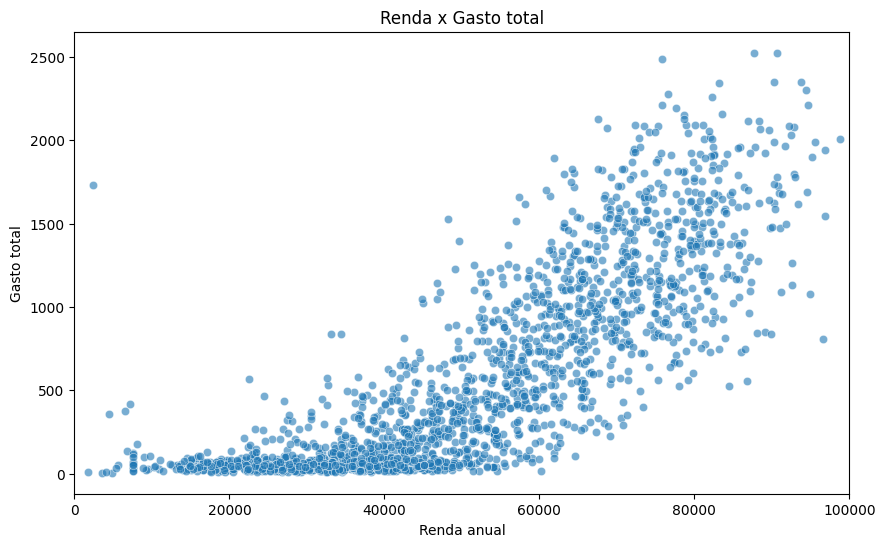

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Income',
    y='TotalSpent',
    alpha=0.6
)

plt.xlim(0, 100000)

plt.title('Renda x Gasto total')
plt.xlabel('Renda anual')
plt.ylabel('Gasto total')

plt.show()

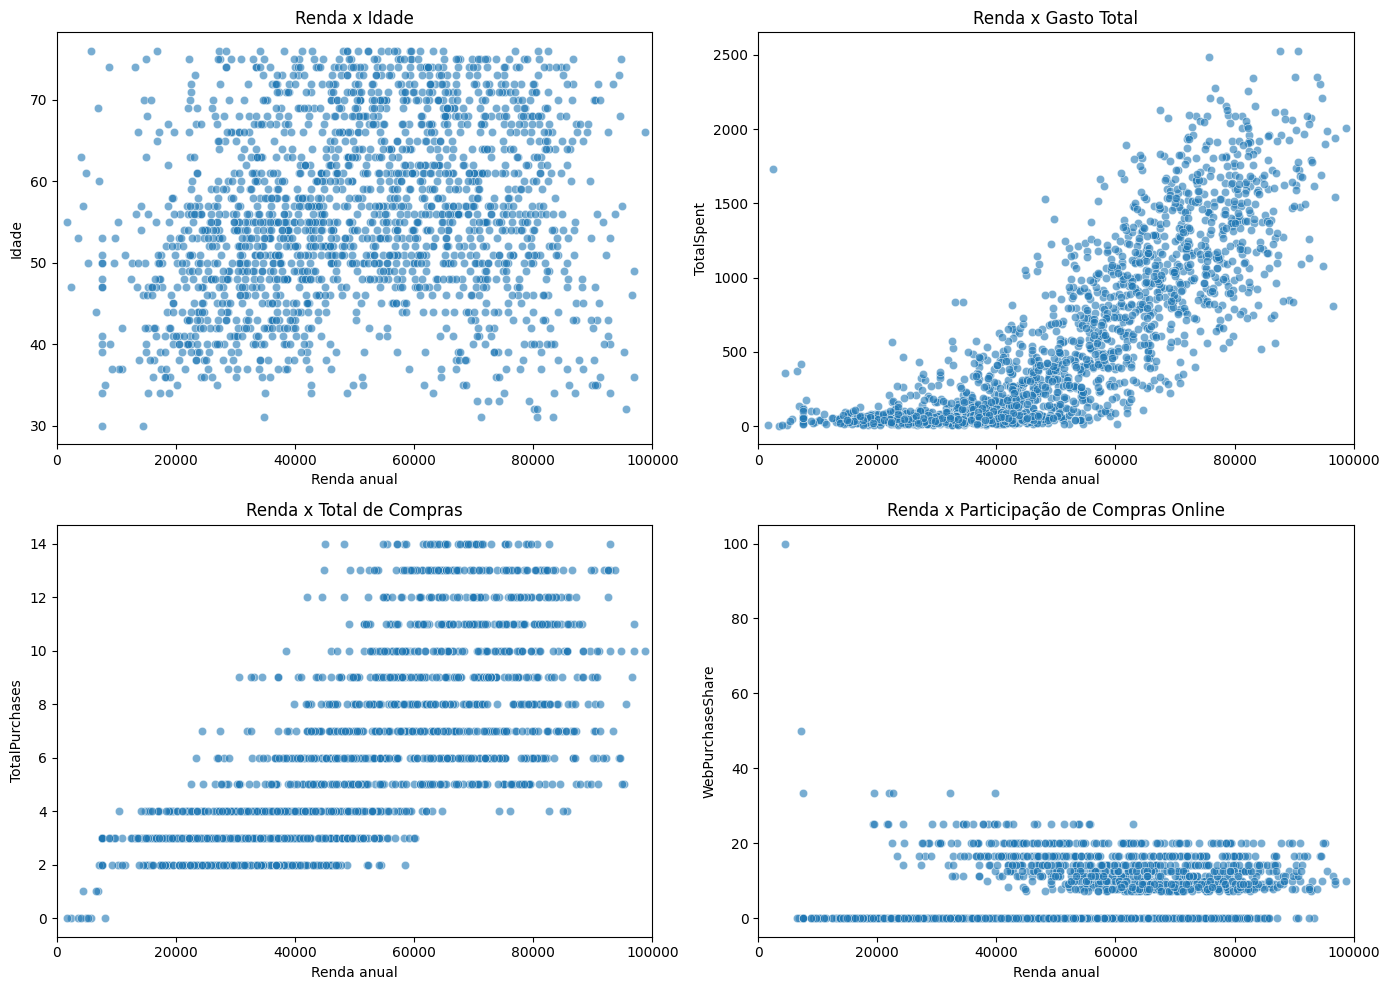

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

graficos = [
    ('Age', 'Renda x Idade'),
    ('TotalSpent', 'Renda x Gasto Total'),
    ('TotalPurchases', 'Renda x Total de Compras'),
    ('WebPurchaseShare', 'Renda x Participação de Compras Online')
]

for ax, (variavel, titulo) in zip(axes.flat, graficos):
    
    if variavel == 'Age':
        sns.scatterplot(
            x=df['Income'],
            y=2026 - df['Year_Birth'],
            alpha=0.6,
            ax=ax
        )
        ax.set_ylabel('Idade')
    else:
        sns.scatterplot(
            data=df,
            x='Income',
            y=variavel,
            alpha=0.6,
            ax=ax
        )
        ax.set_ylabel(variavel)
    
    ax.set_xlim(0, 100000)
    ax.set_title(titulo)
    ax.set_xlabel('Renda anual')

plt.tight_layout()
plt.show()

Os clientes com maior renda tendem a gastar mais e também realizar mais compras. Porém, a idade não parece ter uma relação muito forte com a renda, já que existem clientes de diferentes idades em várias faixas de renda. Além disso, a maioria dos clientes ainda realiza poucas compras pela internet, mesmo entre aqueles que possuem uma renda mais alta. Dessa forma, a empresa pode aproveitar esse comportamento para criar estratégias que incentivem mais compras pelo canal online e aumentem o consumo dos clientes.

# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








In [29]:
correlacao = df.corr(numeric_only=True)

correlacao

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases,TotalSpent,TotalPurchases,WebPurchaseShare,ComprouOnline
Year_Birth,1.000000,-0.151649,-0.021032,-0.135256,0.213011,-0.026744,-0.134075,-0.004497,-0.000138,-0.015878,-0.005820,-0.056647,-0.124235,0.089390,0.005277,-0.139476,-0.081690,-0.133496,-0.103545,-0.139476
Education,-0.151649,1.000000,-0.006943,0.110706,-0.032761,-0.008657,0.186454,-0.098792,0.037400,-0.115272,-0.115513,-0.095117,0.061105,-0.046865,-0.045892,0.078375,0.084502,0.067052,0.064749,0.078375
Marital_Status,-0.021032,-0.006943,1.000000,0.014491,-0.006349,0.011909,-0.000291,-0.016694,0.017297,0.028550,0.009974,-0.013742,-0.013873,-0.020939,0.012296,-0.006286,0.007336,-0.013584,-0.006717,-0.006286
Income,-0.135256,0.110706,0.014491,1.000000,-0.422536,-0.009445,0.562960,0.421683,0.570687,0.429732,0.425712,0.314091,0.521573,-0.532024,-0.025760,0.424635,0.651635,0.537534,0.267701,0.424635
Kidhome,0.213011,-0.032761,-0.006349,-0.422536,1.000000,0.020053,-0.509086,-0.376647,-0.438764,-0.390759,-0.380717,-0.358763,-0.510654,0.437386,0.037470,-0.412639,-0.566265,-0.525838,-0.278004,-0.412639
Recency,-0.026744,-0.008657,0.011909,-0.009445,0.020053,1.000000,0.009415,-0.015797,0.016697,0.001493,0.035403,0.007315,0.003491,-0.012275,-0.004897,-0.003711,0.013676,0.002664,-0.018369,-0.003711
MntWines,-0.134075,0.186454,-0.000291,0.562960,-0.509086,0.009415,1.000000,0.388990,0.556999,0.398571,0.403007,0.398494,0.645762,-0.309139,-0.039890,0.546546,0.890313,0.668486,0.354540,0.546546
MntFruits,-0.004497,-0.098792,-0.016694,0.421683,-0.376647,-0.015797,0.388990,1.000000,0.542297,0.599794,0.565778,0.404959,0.463156,-0.404525,0.002333,0.345714,0.615616,0.472862,0.208176,0.345714
MntMeatProducts,-0.000138,0.037400,0.017297,0.570687,-0.438764,0.016697,0.556999,0.542297,1.000000,0.563357,0.537781,0.351054,0.475370,-0.522965,-0.018566,0.385131,0.841017,0.489648,0.257059,0.385131
MntFishProducts,-0.015878,-0.115272,0.028550,0.429732,-0.390759,0.001493,0.398571,0.599794,0.563357,1.000000,0.587298,0.432736,0.465452,-0.432518,-0.019577,0.335952,0.642707,0.473572,0.208182,0.335952


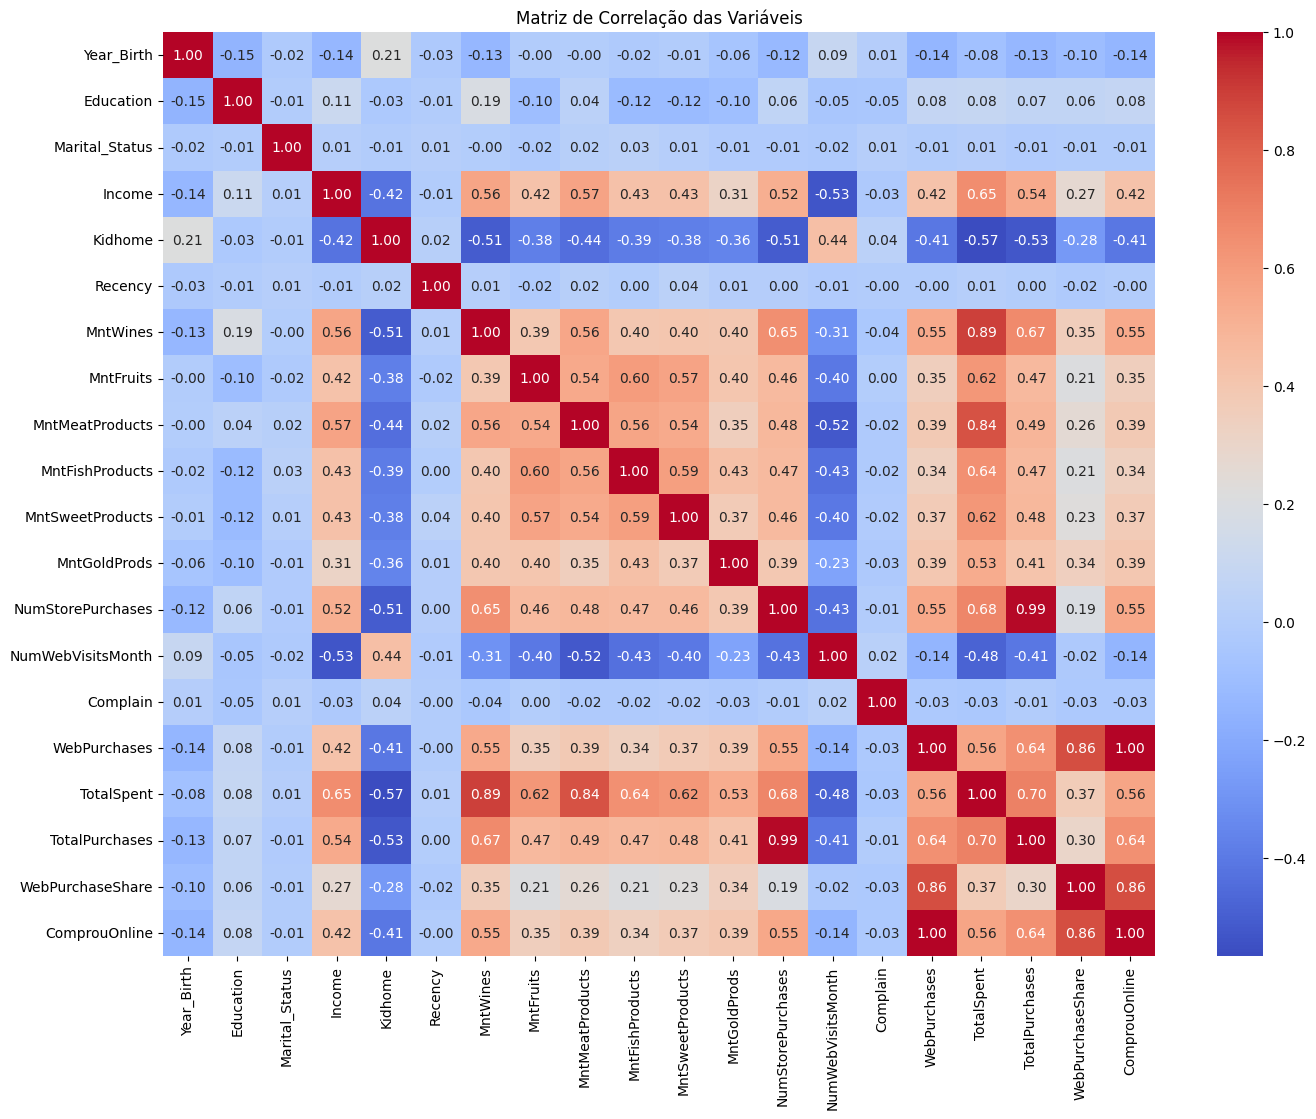

In [30]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação das Variáveis')
plt.show()

In [31]:
colunas_numericas = [
    "Income",
    "Kidhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "WebPurchases",
    "TotalSpent",
    "TotalPurchases",
    "WebPurchaseShare"
]

scaler = StandardScaler()

df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])

In [32]:
df.head(5)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases,TotalSpent,TotalPurchases,WebPurchaseShare,ComprouOnline
0,1957,2,4,0.248406,-0.852877,0.306303,1.026814,1.570895,1.710353,2.491151,1.500399,0.860004,-0.538292,0.670159,0,1.003133,1.724186,-0.349468,1.703783,1
1,1954,2,4,-0.210958,1.003897,-0.383927,-0.858495,-0.631370,-0.700438,-0.640122,-0.627818,-0.725577,-1.161184,-0.154851,0,-0.996877,-0.947595,-1.204053,-0.859293,0
2,1965,2,5,0.773245,-0.852877,-0.798065,0.395356,0.583673,-0.160242,1.367577,-0.138573,-0.029468,1.330384,-0.567356,0,1.003133,0.310999,1.359703,0.305741,1
3,1984,2,5,-0.978176,1.003897,-0.798065,-0.858495,-0.555430,-0.637936,-0.492768,-0.578894,-0.744914,-0.538292,0.257654,0,-0.996877,-0.903905,-0.634330,-0.859293,0
4,1981,4,3,0.254444,1.003897,1.548717,-0.369040,0.431793,-0.200422,0.170325,0.008201,-0.551550,0.084600,-0.154851,0,1.003133,-0.283850,0.220255,0.971476,1


Income × TotalSpent (0,65) — correlação positiva moderada/forte entre a renda e o gasto total. Clientes com maior renda tendem a gastar mais.
Income × TotalPurchases (0,54) — correlação positiva moderada entre a renda e o número total de compras. Clientes com maior renda tendem a realizar mais compras.
Income × MntWines (0,56) — correlação positiva moderada entre a renda e o gasto com vinhos. Clientes com maior renda tendem a gastar mais com essa categoria.
Kidhome × TotalSpent (-0,57) — correlação negativa moderada entre o número de crianças em casa e o gasto total. Clientes com mais crianças tendem a apresentar menor gasto.
NumWebVisitsMonth × TotalSpent (-0,48) — correlação negativa moderada entre o número de visitas ao site e o gasto total. Clientes que visitam mais o site não são necessariamente os que mais gastam, o que pode indicar uma oportunidade de transformar visitas em compras.

Sim, há espaço para redução do número de variáveis e dentro do modelo vou incluir somente Income,TotalSpent, TotalPurchases,Kidhome e NumWebVisitsMonth.


In [50]:
#X = df[['Income','TotalSpent', 'TotalPurchases','Kidhome','NumWebVisitsMonth']] dps do pca renda removida-testei com 4 tbm
X = df[['TotalSpent', 'TotalPurchases','Kidhome','NumWebVisitsMonth']]
y = df['ComprouOnline']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)

In [46]:
pca_5 = PCA(n_components = 5)
pca_5.fit(X)
explained_variance = pca_5.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

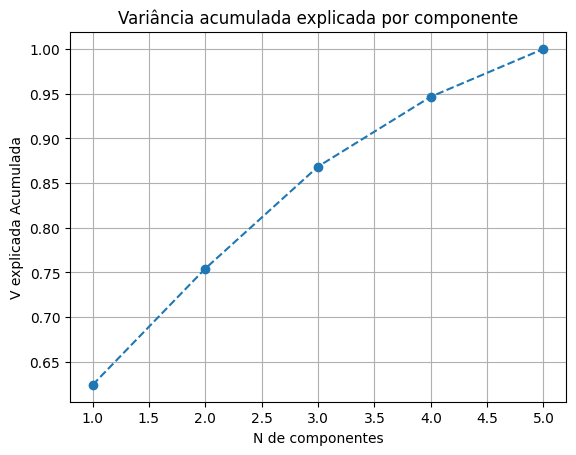

In [48]:
plt.plot(range(1,6), cumulative_variance, marker ='o', linestyle = '--')
plt.title('Variância acumulada explicada por componente')
plt.xlabel('N de componentes')
plt.ylabel('V explicada Acumulada')
plt.grid(True)
plt.show()

In [49]:
print(cumulative_variance)

[0.62420249 0.75431225 0.8683977  0.94652778 1.        ]


4 variáveis já explicam 95% da variabilidade dos dados, sendo a renda a que possui menor desempenho ela foi removida.

# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

In [60]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Matriz de Confusão")
print(confusion_matrix(y_test, y_pred))
print("Relatório de Classificação")
print(classification_report(y_test, y_pred))

Matriz de Confusão
[[171  29]
 [ 13 171]]
Relatório de Classificação
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       200
           1       0.85      0.93      0.89       184

    accuracy                           0.89       384
   macro avg       0.89      0.89      0.89       384
weighted avg       0.89      0.89      0.89       384



Com o tratamento dos dados e o uso do random forest o modelo entregou uma excelente acurácia 0.89 o que sinifica que 89% do total de previsões 
estavam corretas. Com o recall de 0.85, 85% das previsões em relação ao total real estavam corretas. 
Matriz de Confusão
               Não compra     Compra
  Não compra:   [171           29]
  Compra:       [ 13          171]

#171: eram não compra e ele acertou, 29 ele errou apontando como compra mas não era.
#13:  eram compra e ele disse não compra, 171 eram compra e ele acertou.

o modelo teve 29 falsos positivos e 13 falsos negativos, além de 171 verdadeiros negativos e 171 verdadeiros positivos.

In [70]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório:")
print(classification_report(y_test, y_pred))


Matriz de Confusão:
[[168  32]
 [ 26 158]]

Relatório:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       200
           1       0.83      0.86      0.84       184

    accuracy                           0.85       384
   macro avg       0.85      0.85      0.85       384
weighted avg       0.85      0.85      0.85       384



Com o tratamento dos dados e o uso da regressão logística o modelo entregou uma excelente acurácia 0.85 o que sinifica que 85% do total de previsões 
estavam corretas. Com o recall de 0.84, 84% das previsões em relação ao total real estavam corretas. 
Matriz de Confusão
               Não compra     Compra
  Não compra:   [168           32]
  Compra:       [ 26          158]

#168: eram não compra e ele acertou, 29 ele errou apontando como compra mas não era.
#26:  eram compra e ele disse não compra, 171 eram compra e ele acertou.

o modelo teve 32 falsos positivos e 26 falsos negativos, além de 168 verdadeiros negativos e 158 verdadeiros positivos.

# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

In [ ]:
# seu código aqui

Sou a tutora Amanda e serei responsável pela correção da sua atividade.

Parabéns pelo comprometimento demonstrado durante o desenvolvimento do projeto! Você realizou a preparação dos dados de forma adequada, incluindo as etapas de análise exploratória e tratamento da base para garantir sua qualidade antes da modelagem. A construção do storytelling foi elaborada, utilizando gráficos para destacar padrões. Você verificou a relação entre as variáveis por meio da análise de correlação, identificando oportunidades de otimização do conjunto de dados. As variáveis categóricas foram convertidas para um formato compatível com os algoritmos de machine learning, e a divisão entre os conjuntos de treino e teste foi realizada corretamente. Além disso, aplicou a padronização dos dados, tornando o processo de treinamento mais consistente. Na etapa de modelagem, implementou dois algoritmos distintos e comparou seus resultados utilizando métricas de avaliação e a matriz de confusão.

O que seria legal é construir um README para descrever todo o projeto de ponta a ponta desde da EDA, tratamento, técnicas necessárias para implementação de um modelo, parâmetros necessários , um parágrafo sobre a regressão logística e do random florest e terminar com as conclusões finais sobre cada métrica do modelo e seus insights.

Continue construindo um bom storytelling nas devolutivas dos projetos que você vai ganhando muita prática.